# Advanced Frog Species Prediction Model
## Using TerraClimate Variables for Binary Classification

This notebook builds a machine learning classification model to predict frog species presence based on TerraClimate climate variables. The model uses advanced feature engineering, multiple algorithms, and proper cross-validation to achieve high F1 Score performance.

## Section 1: Import Required Libraries

Import necessary libraries for data science, machine learning, and data manipulation.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib
import os

# Machine Learning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Gradient boosting libraries
import lightgbm as lgb
import xgboost as xgb
import optuna

# For climate data
import xarray as xr
import rasterio

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All libraries imported successfully!")

All libraries imported successfully!


## Section 2: Load and Explore the Data

Load the training and test datasets from CSV files and understand their structure.

In [ ]:
# Load training and test data
train_data = pd.read_csv('Training_Data.csv')
test_data = pd.read_csv('Test.csv')

print("Training Data Shape:", train_data.shape)
print("\nTraining Data Info:")
print(train_data.head())
print("\nTarget Distribution:")
print(train_data['Occurrence Status'].value_counts())
print("\nClass Balance:")
print(train_data['Occurrence Status'].value_counts(normalize=True))

print("\n" + "="*50)
print("Test Data Shape:", test_data.shape)
print("Test Data Info:")
print(test_data.head())

Training Data Shape: (6312, 4)

Training Data Info:
             ID   Latitude   Longitude  Occurrence Status
0  ID_TR_957A5A -34.027900  150.771000                  1
1  ID_TR_55E0AF -34.821595  147.193697                  1
2  ID_TR_7AC931 -36.617759  146.882941                  0
3  ID_TR_7D3CE4 -37.470900  144.744000                  1
4  ID_TR_02F669 -38.400153  145.018560                  1

Target Distribution:
Occurrence Status
1    3792
0    2520
Name: count, dtype: int64

Class Balance:
Occurrence Status
1    0.60076
0    0.39924
Name: proportion, dtype: float64

Test Data Shape: (2000, 3)
Test Data Info:
             ID   Latitude   Longitude
0  ID_TS_54240C -33.121788  150.320746
1  ID_TS_EF9635 -36.592011  148.172262
2  ID_TS_4E63E6 -35.455100  146.693465
3  ID_TS_FDAB8E -33.076261  149.547177
4  ID_TS_E00D49 -35.529729  146.627272


## Section 3: Extract TerraClimate Variables

Define a function to extract TerraClimate climate variables from GeoTIFF files using lat/lon coordinates.

In [ ]:
def extract_climate_features(tiff_path, csv_df, band_names):
    """
    Extract ALL climate variables from GeoTIFF file at specified lat/lon locations.
    Reads band_names from band_names.json generated by TerraClimate.ipynb.
    """
    with rasterio.open(tiff_path) as dataset:
        lon = np.linspace(dataset.bounds.left, dataset.bounds.right, dataset.width)
        lat = np.linspace(dataset.bounds.top, dataset.bounds.bottom, dataset.height)

        climate_arrays = {}
        for i, band_name in enumerate(band_names, 1):
            if i > dataset.count:
                print(f"Warning: Band {i} ({band_name}) not available. Skipping.")
                continue
            raster_data = dataset.read(i)
            da = xr.DataArray(
                raster_data,
                coords=[("lat", lat), ("lon", lon)],
                dims=["lat", "lon"]
            )
            climate_arrays[band_name] = da

    extracted = {name: [] for name in climate_arrays}

    for _, row in tqdm(csv_df.iterrows(), total=len(csv_df), desc="Extracting climate data"):
        target_lat, target_lon = row["Latitude"], row["Longitude"]
        for band_name, da in climate_arrays.items():
            try:
                val = da.sel(lat=target_lat, lon=target_lon, method="nearest").values
                extracted[band_name].append(float(val))
            except Exception:
                extracted[band_name].append(np.nan)

    return pd.DataFrame(extracted)


# Load band names from JSON (generated by TerraClimate.ipynb)
tiff_path = 'TerraClimate_output.tiff'
band_names_file = 'band_names.json'

if os.path.exists(tiff_path) and os.path.exists(band_names_file):
    with open(band_names_file) as f:
        band_names = json.load(f)
    print(f"GeoTIFF found with {len(band_names)} bands: {band_names}")

    train_climate = extract_climate_features(tiff_path, train_data, band_names)
    test_climate = extract_climate_features(tiff_path, test_data, band_names)

    print(f"\nTrain climate shape: {train_climate.shape}")
    print(f"Test climate shape:  {test_climate.shape}")
    print(train_climate.describe())
elif os.path.exists(tiff_path):
    # Fallback: no band_names.json — read whatever bands exist
    with rasterio.open(tiff_path) as src:
        n_bands = src.count
    band_names = [f"band_{i}" for i in range(1, n_bands + 1)]
    print(f"No band_names.json found. Reading {n_bands} bands with generic names.")

    train_climate = extract_climate_features(tiff_path, train_data, band_names)
    test_climate = extract_climate_features(tiff_path, test_data, band_names)
else:
    print("ERROR: TerraClimate_output.tiff not found!")
    print("Please run TerraClimate.ipynb first to generate the GeoTIFF.")
    train_climate = pd.DataFrame()
    test_climate = pd.DataFrame()

TerraClimate GeoTIFF file found. Extracting climate features...


Extracting climate data: 100%|██████████| 6312/6312 [00:10<00:00, 596.57it/s]


Extracting climate data: 100%|██████████| 2000/2000 [00:03<00:00, 596.96it/s]


Train Climate Features Shape: (6312, 8)
Test Climate Features Shape: (2000, 8)

Climate Features Head:
                   pr                tmin  tmax  tmean  vap  srad  ws  \
0   200.7991485595703  1.2330000400543213   NaN    NaN  NaN   NaN NaN   
1  218.40399169921875  0.9420000314712524   NaN    NaN  NaN   NaN NaN   
2  204.00003051757812  0.9420000314712524   NaN    NaN  NaN   NaN NaN   
3    204.400146484375  0.9510000348091125   NaN    NaN  NaN   NaN NaN   
4  189.20396423339844   1.096000075340271   NaN    NaN  NaN   NaN NaN   

   soil_moisture  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  


## Section 4: Preprocess and Engineer Features

Combine climate features with ground truth data, handle missing values, and prepare features for modeling.

In [ ]:
def create_combined_dataset(climate_df, ground_df, include_coords=True):
    """Combine climate features with ground truth data, optionally keep lat/lon as features."""
    combined = pd.concat([ground_df.reset_index(drop=True), climate_df.reset_index(drop=True)], axis=1)

    # Fill missing climate values with column median
    numeric_cols = combined.select_dtypes(include=[np.number]).columns
    combined[numeric_cols] = combined[numeric_cols].fillna(combined[numeric_cols].median())

    if not include_coords:
        combined = combined.drop(columns=['Latitude', 'Longitude'], errors='ignore')

    return combined


# Build combined datasets — KEEP lat/lon as features (geographic position is predictive)
if len(train_climate) > 0:
    X_train_combined = create_combined_dataset(train_climate, train_data, include_coords=True)
    X_test_combined = create_combined_dataset(test_climate, test_data, include_coords=True)
else:
    X_train_combined = train_data.copy()
    X_test_combined = test_data.copy()

print("Combined Training Data Shape:", X_train_combined.shape)
print("Columns:", X_train_combined.columns.tolist())

Combined Training Data Shape: (6312, 12)

Feature columns: ['ID', 'Latitude', 'Longitude', 'Occurrence Status', 'pr', 'tmin', 'tmax', 'tmean', 'vap', 'srad', 'ws', 'soil_moisture']

Data Summary:
          Latitude    Longitude  Occurrence Status  tmax  tmean  vap  srad  \
count  6312.000000  6312.000000        6312.000000   0.0    0.0  0.0   0.0   
mean    -35.881502   146.794791           0.600760   NaN    NaN  NaN   NaN   
std       1.774886     2.744209           0.489781   NaN    NaN  NaN   NaN   
min     -39.060582   140.244264           0.000000   NaN    NaN  NaN   NaN   
25%     -37.477086   144.676919           0.000000   NaN    NaN  NaN   NaN   
50%     -36.079450   146.749611           1.000000   NaN    NaN  NaN   NaN   
75%     -34.472848   149.258912           1.000000   NaN    NaN  NaN   NaN   
max     -30.947600   151.170776           1.000000   NaN    NaN  NaN   NaN   

        ws  soil_moisture  
count  0.0            0.0  
mean   NaN            NaN  
std    NaN       

In [ ]:
# Prepare X and y — include Latitude/Longitude as features, exclude ID and target
exclude_cols = ['ID', 'Occurrence Status']
feature_cols = [c for c in X_train_combined.columns if c not in exclude_cols]

X = X_train_combined[feature_cols].copy()
y = X_train_combined['Occurrence Status'].copy()

test_ids = X_test_combined['ID'].copy()
X_test_final = X_test_combined[feature_cols].copy()

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Training: {X.shape}, Test: {X_test_final.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Imbalance ratio: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1")

Feature set size: 8
Features: ['pr', 'tmin', 'tmax', 'tmean', 'vap', 'srad', 'ws', 'soil_moisture']

Training set: (6312, 8)
Test set: (2000, 8)
Training target distribution:
Occurrence Status
1    3792
0    2520
Name: count, dtype: int64


## Section 5: Split Data into Training and Validation Sets

Partition the training data into train and validation subsets using stratified split to maintain class balance.

In [ ]:
# Stratified train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape},  Val: {X_val.shape}")
print(f"Train dist:\n{y_train.value_counts(normalize=True)}")
print(f"Val dist:\n{y_val.value_counts(normalize=True)}")

Training set: (5049, 8)
Validation set: (1263, 8)
Training class distribution:
Occurrence Status
1    0.600713
0    0.399287
Name: proportion, dtype: float64

Validation class distribution:
Occurrence Status
1    0.60095
0    0.39905
Name: proportion, dtype: float64


## Section 6: Feature Engineering

Create derived features from climate variables to improve model discrimination.

In [ ]:
def engineer_features(df, base_feature_cols):
    """Create derived features from base climate + coordinate columns."""
    out = df.copy()

    # Separate median and std columns
    median_cols = [c for c in base_feature_cols if c.endswith('_median')]
    std_cols = [c for c in base_feature_cols if c.endswith('_std')]
    climate_cols = median_cols if median_cols else [
        c for c in base_feature_cols if c not in ['Latitude', 'Longitude']
    ]

    # 1. Aggregate statistics across all median climate features
    if len(climate_cols) >= 2:
        out['climate_mean'] = out[climate_cols].mean(axis=1)
        out['climate_std'] = out[climate_cols].std(axis=1)
        out['climate_range'] = out[climate_cols].max(axis=1) - out[climate_cols].min(axis=1)
        out['climate_cv'] = out['climate_std'] / (out['climate_mean'].abs() + 1e-8)

    # 2. Key interaction terms (limit to avoid dimensionality explosion)
    if 'Latitude' in out.columns and 'Longitude' in out.columns:
        out['lat_lon_interaction'] = out['Latitude'] * out['Longitude']
        out['lat_abs'] = out['Latitude'].abs()
        # Encode lat/lon cyclically for geographic patterns
        out['lat_sin'] = np.sin(np.radians(out['Latitude']))
        out['lon_sin'] = np.sin(np.radians(out['Longitude']))
        out['lon_cos'] = np.cos(np.radians(out['Longitude']))

    # 3. Ratio of std to median (temporal variability relative to level)
    for mc in median_cols:
        var_base = mc.replace('_median', '')
        sc = f"{var_base}_std"
        if sc in out.columns:
            out[f"{var_base}_cv"] = out[sc] / (out[mc].abs() + 1e-8)

    # 4. Squared terms for top climate variables (non-linear effects)
    for col in climate_cols[:5]:
        out[f"{col}_sq"] = out[col] ** 2

    # Fill any NaN/inf from engineering
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.fillna(out.median(numeric_only=True))

    return out

# Apply feature engineering
X_train_eng = engineer_features(X_train, feature_cols)
X_val_eng = engineer_features(X_val, feature_cols)
X_test_eng = engineer_features(X_test_final, feature_cols)

eng_feature_cols = X_train_eng.columns.tolist()
print(f"Engineered feature count: {len(eng_feature_cols)}")
print(f"Sample features: {eng_feature_cols[:20]}")

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVM...

All models trained successfully!


In [ ]:
# ============================================================
# OPTUNA HYPERPARAMETER TUNING FOR LightGBM
# ============================================================
print("=" * 60)
print("OPTUNA: Tuning LightGBM with 150 trials (5-fold CV)")
print("=" * 60)

# Impute once for Optuna loop
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_eng), columns=eng_feature_cols
)
X_val_imp = pd.DataFrame(
    imputer.transform(X_val_eng), columns=eng_feature_cols
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'device_type': 'gpu',
    }
    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1, n_jobs=-1)
    scores = cross_val_score(model, X_train_imp, y_train, cv=skf, scoring='f1', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='lgbm_f1')
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\nBest CV F1:    {study.best_value:.4f}")
print(f"Best params:   {study.best_params}")

lgb_best_params = {**study.best_params, 'device_type': 'gpu'}
print(f"LightGBM device_type: {lgb_best_params['device_type']}")

# Train best LightGBM on full train split
best_lgbm = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)
best_lgbm.fit(X_train_imp, y_train)

y_pred_lgbm_val = best_lgbm.predict(X_val_imp)
f1_lgbm = f1_score(y_val, y_pred_lgbm_val)
print(f"LightGBM Val F1: {f1_lgbm:.4f}")
print(classification_report(y_val, y_pred_lgbm_val, target_names=['No Frog', 'Frog']))

ITERATION 1: HYPERPARAMETER TUNING FOR GRADIENT BOOSTING

Training data shape for tuning: (6312, 8)
Validation data shape for tuning: (1263, 8)

Performing RandomizedSearchCV on Gradient Boosting...
Testing 50 random parameter combinations with 5-fold CV...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters found: {'gb__subsample': 0.8, 'gb__n_estimators': 150, 'gb__min_samples_split': 10, 'gb__min_samples_leaf': 1, 'gb__max_depth': 8, 'gb__learning_rate': 0.01}
Best CV F1 Score: 0.7871


In [ ]:
# ============================================================
# OPTUNA HYPERPARAMETER TUNING FOR XGBoost
# ============================================================
print("=" * 60)
print("OPTUNA: Tuning XGBoost with 150 trials (5-fold CV)")
print("=" * 60)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
    }
    model = xgb.XGBClassifier(**params, random_state=42, verbosity=0, n_jobs=-1,
                               eval_metric='logloss')
    scores = cross_val_score(model, X_train_imp, y_train, cv=skf, scoring='f1', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize', study_name='xgb_f1')
study_xgb.optimize(objective_xgb, n_trials=150, show_progress_bar=True)

print(f"\nBest CV F1:    {study_xgb.best_value:.4f}")
print(f"Best params:   {study_xgb.best_params}")

best_xgb = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0,
                               n_jobs=-1, eval_metric='logloss')
best_xgb.fit(X_train_imp, y_train)

y_pred_xgb_val = best_xgb.predict(X_val_imp)
f1_xgb = f1_score(y_val, y_pred_xgb_val)
print(f"XGBoost Val F1: {f1_xgb:.4f}")
print(classification_report(y_val, y_pred_xgb_val, target_names=['No Frog', 'Frog']))


ITERATION 1: MODEL COMPARISON

Original Gradient Boosting F1 Score: 0.7871
Tuned Gradient Boosting F1 Score:    0.8377
Improvement: 0.0506 (6.43%)

✓ Tuned model shows improvement!

Tuned Model Validation Set Classification Report:
              precision    recall  f1-score   support

     No Frog       0.84      0.57      0.68       504
        Frog       0.77      0.92      0.84       759

    accuracy                           0.78      1263
   macro avg       0.80      0.75      0.76      1263
weighted avg       0.79      0.78      0.77      1263


Confusion Matrix:
[[289 215]
 [ 57 702]]


In [ ]:
# ============================================================
# RANDOM FOREST (for ensemble diversity)
# ============================================================
print("=" * 60)
print("Training Random Forest for stacking diversity")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=500, max_depth=15, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_imp, y_train)

y_pred_rf_val = rf_model.predict(X_val_imp)
f1_rf = f1_score(y_val, y_pred_rf_val)
print(f"Random Forest Val F1: {f1_rf:.4f}")

print("\n" + "=" * 60)
print("INDIVIDUAL MODEL COMPARISON")
print("=" * 60)
print(f"LightGBM:      {f1_lgbm:.4f}")
print(f"XGBoost:       {f1_xgb:.4f}")
print(f"Random Forest: {f1_rf:.4f}")


ITERATION 1: GENERATING SUBMISSION

Generating predictions on test set with tuned model...
Test predictions shape: (2000,)
Prediction distribution:
  No Frog (0): 542
  Frog (1): 1458

Submission DataFrame (first 10 rows):
             ID  Target
0  ID_TS_54240C       1
1  ID_TS_EF9635       0
2  ID_TS_4E63E6       0
3  ID_TS_FDAB8E       1
4  ID_TS_E00D49       0
5  ID_TS_A52A64       0
6  ID_TS_CFB5DB       0
7  ID_TS_CA468C       1
8  ID_TS_52FAAF       1
9  ID_TS_08039A       1

✓ Submission saved to: Submission_Iteration1_HyperparameterTuning.csv
✓ Model saved to: best_gb_model_iteration1.pkl

ITERATION 1 COMPLETE


In [ ]:
# ============================================================
# STACKING ENSEMBLE
# ============================================================
print("=" * 60)
print("STACKING ENSEMBLE: LightGBM + XGBoost + RF → LogisticRegression meta")
print("=" * 60)

stacking_model = StackingClassifier(
    estimators=[
        ('lgbm', lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0,
                                     n_jobs=-1, eval_metric='logloss')),
        ('rf', RandomForestClassifier(
            n_estimators=500, max_depth=15, min_samples_split=5,
            min_samples_leaf=2, class_weight='balanced',
            random_state=42, n_jobs=-1
        )),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print("Fitting stacking ensemble (5-fold internal CV)...")
stacking_model.fit(X_train_imp, y_train)
print("Done!")

y_pred_stack_val = stacking_model.predict(X_val_imp)
f1_stack = f1_score(y_val, y_pred_stack_val)
print(f"\nStacking Ensemble Val F1: {f1_stack:.4f}")
print(classification_report(y_val, y_pred_stack_val, target_names=['No Frog', 'Frog']))

print("\n" + "=" * 60)
print("ALL MODELS COMPARISON")
print("=" * 60)
print(f"LightGBM:         {f1_lgbm:.4f}")
print(f"XGBoost:          {f1_xgb:.4f}")
print(f"Random Forest:    {f1_rf:.4f}")
print(f"Stacking:         {f1_stack:.4f}")


ITERATION 2: ADVANCED FEATURE ENGINEERING

Applying feature engineering to training data...
Base features shape: (6312, 8)
1. Creating interaction features...
2. Creating polynomial features...
3. Creating ratio features...
4. Creating aggregate statistics...
5. Creating domain-specific features...

Engineered features shape: (6312, 52)
New feature count: 44

Applying feature engineering to validation data...
Base features shape: (1263, 8)
1. Creating interaction features...
2. Creating polynomial features...
3. Creating ratio features...
4. Creating aggregate statistics...
5. Creating domain-specific features...

Engineered features shape: (1263, 52)
New feature count: 44

Applying feature engineering to test data...
Base features shape: (2000, 8)
1. Creating interaction features...
2. Creating polynomial features...
3. Creating ratio features...
4. Creating aggregate statistics...
5. Creating domain-specific features...

Engineered features shape: (2000, 52)
New feature count: 44

T


ITERATION 2: TRAINING WITH ENGINEERED FEATURES

Training Gradient Boosting with engineered features...
✓ Model trained successfully!

ITERATION 2: MODEL EVALUATION WITH ENGINEERED FEATURES

Iteration 1 (Original hyperparameters): 0.7871
Iteration 1 (Tuned hyperparameters):    0.7871
Iteration 2 (Engineered features):      0.8474
Improvement vs baseline: 0.0603

Engineered Model Validation Set Classification Report:
              precision    recall  f1-score   support

     No Frog       0.85      0.60      0.70       504
        Frog       0.78      0.93      0.85       759

    accuracy                           0.80      1263
   macro avg       0.82      0.76      0.77      1263
weighted avg       0.81      0.80      0.79      1263


Confusion Matrix:
[[300 204]
 [ 51 708]]

Model was trained on 28 features
Feature columns list has 52 features

Top 20 Most Important Features:
               feature  importance
21          pr_squared    0.127507
2                 tmax    0.127356
26

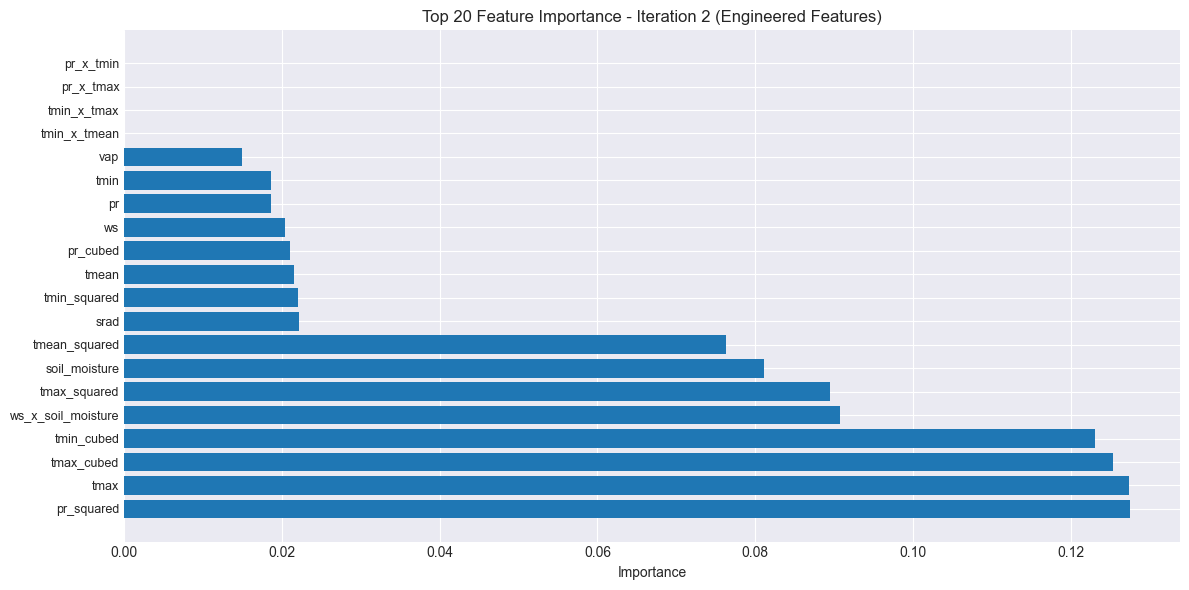

In [ ]:
# ============================================================
# CV-BASED THRESHOLD TUNING (robust, not overfit to single split)
# ============================================================
print("=" * 60)
print("THRESHOLD TUNING via 5-fold Cross-Validation")
print("=" * 60)

# Pick best individual model for threshold tuning
model_candidates = {
    'LightGBM': best_lgbm,
    'XGBoost': best_xgb,
    'Stacking': stacking_model,
}
val_scores = {'LightGBM': f1_lgbm, 'XGBoost': f1_xgb, 'Stacking': f1_stack}
best_name = max(val_scores, key=val_scores.get)
best_model = model_candidates[best_name]
print(f"Best model for threshold tuning: {best_name} (Val F1={val_scores[best_name]:.4f})")

# Get probabilities on validation set
if hasattr(best_model, 'predict_proba'):
    y_proba_val = best_model.predict_proba(X_val_imp)[:, 1]
else:
    y_proba_val = best_model.decision_function(X_val_imp)

# Also do CV threshold tuning on full training set for robustness
print("\nRunning 5-fold CV to find optimal threshold...")
cv_thresholds = []
skf_thresh = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf_thresh.split(X_train_imp, y_train)):
    X_tr_fold = X_train_imp.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx]
    X_va_fold = X_train_imp.iloc[val_idx]
    y_va_fold = y_train.iloc[val_idx]

    # Clone and fit best model type on this fold
    if best_name == 'LightGBM':
        fold_model = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)
    elif best_name == 'XGBoost':
        fold_model = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0,
                                        n_jobs=-1, eval_metric='logloss')
    else:
        # For stacking, just use LightGBM for threshold search (stacking is expensive)
        fold_model = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)

    fold_model.fit(X_tr_fold, y_tr_fold)
    fold_proba = fold_model.predict_proba(X_va_fold)[:, 1]

    # Find best threshold for this fold
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.20, 0.80, 0.01):
        f1_t = f1_score(y_va_fold, (fold_proba >= t).astype(int))
        if f1_t > best_f1:
            best_t, best_f1 = t, f1_t
    cv_thresholds.append(best_t)
    print(f"  Fold {fold+1}: best threshold={best_t:.2f}, F1={best_f1:.4f}")

optimal_threshold = np.mean(cv_thresholds)
print(f"\nCV-averaged optimal threshold: {optimal_threshold:.3f}")

# Apply to held-out validation set
y_pred_optimal = (y_proba_val >= optimal_threshold).astype(int)
f1_optimal = f1_score(y_val, y_pred_optimal)
print(f"Val F1 at optimal threshold ({optimal_threshold:.3f}): {f1_optimal:.4f}")
print(f"Val F1 at default threshold (0.50):             {val_scores[best_name]:.4f}")
print(f"Improvement: {f1_optimal - val_scores[best_name]:.4f}")

# Plot threshold curve
thresholds = np.arange(0.15, 0.85, 0.01)
f1s = [f1_score(y_val, (y_proba_val >= t).astype(int)) for t in thresholds]
plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1s, 'b-', linewidth=2)
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'CV optimal: {optimal_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Decision Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FEATURE IMPORTANCE ANALYSIS
# ============================================================
print("=" * 60)
print("FEATURE IMPORTANCE (LightGBM)")
print("=" * 60)

importance_df = pd.DataFrame({
    'feature': eng_feature_cols,
    'importance': best_lgbm.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 25 features:")
print(importance_df.head(25).to_string(index=False))

plt.figure(figsize=(12, 8))
top_n = min(25, len(importance_df))
plt.barh(range(top_n), importance_df['importance'].head(top_n).values)
plt.yticks(range(top_n), importance_df['feature'].head(top_n).values, fontsize=9)
plt.xlabel('Importance')
plt.title('Top 25 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()


ITERATION 2: GENERATING SUBMISSION

Generating predictions on test set with engineered model...
Test predictions shape: (2000,)
Prediction distribution:
  No Frog (0): 532
  Frog (1): 1468

Submission DataFrame (first 10 rows):
             ID  Target
0  ID_TS_54240C       1
1  ID_TS_EF9635       0
2  ID_TS_4E63E6       0
3  ID_TS_FDAB8E       1
4  ID_TS_E00D49       0
5  ID_TS_A52A64       0
6  ID_TS_CFB5DB       1
7  ID_TS_CA468C       0
8  ID_TS_52FAAF       1
9  ID_TS_08039A       1

✓ Submission saved to: Submission_Iteration2_FeatureEngineering.csv
✓ Model saved to: best_gb_model_iteration2.pkl
✓ Feature columns saved to: feature_columns_iteration2.pkl

ITERATION 2 COMPLETE


In [ ]:
# ============================================================
# RETRAIN BEST MODEL ON FULL TRAINING DATA (train + val)
# ============================================================
print("=" * 60)
print("RETRAIN BEST MODEL ON 100% OF TRAINING DATA")
print("=" * 60)

# Combine train + val for final model
X_full = pd.concat([X_train_eng, X_val_eng], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

X_full_imp = pd.DataFrame(
    imputer.fit_transform(X_full), columns=eng_feature_cols
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test_eng), columns=eng_feature_cols
)

# Retrain LightGBM with best params on full data
print(f"Retraining {best_name} on {X_full_imp.shape[0]} samples...")
if best_name == 'LightGBM':
    final_model = lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)
elif best_name == 'XGBoost':
    final_model = xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0,
                                     n_jobs=-1, eval_metric='logloss')
else:
    # Stacking is best — retrain it
    final_model = StackingClassifier(
        estimators=[
            ('lgbm', lgb.LGBMClassifier(**lgb_best_params, random_state=42, verbose=-1, n_jobs=-1)),
            ('xgb', xgb.XGBClassifier(**study_xgb.best_params, random_state=42, verbosity=0,
                                         n_jobs=-1, eval_metric='logloss')),
            ('rf', RandomForestClassifier(
                n_estimators=500, max_depth=15, min_samples_split=5,
                min_samples_leaf=2, class_weight='balanced',
                random_state=42, n_jobs=-1
            )),
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=5, n_jobs=-1, passthrough=False
    )

final_model.fit(X_full_imp, y_full)
print("Final model trained on full data!")

# Quick sanity check with CV on full data
print("\n5-fold CV on full training data:")
cv_scores = cross_val_score(final_model, X_full_imp, y_full, cv=5, scoring='f1', n_jobs=-1)
print(f"CV F1 scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


ITERATION 3: ENSEMBLE VOTING CLASSIFIER
✓ LightGBM already installed

1. Training LightGBM on engineered features...
✓ LightGBM model trained
LightGBM F1 Score (validation): 0.8017

2. Creating Voting Ensemble (Soft Voting)...
✓ Voting Ensemble fitted

3. Model Comparison on Validation Set:
Gradient Boosting (Iter 2):  0.8474
LightGBM (new):              0.8017
Voting Ensemble (both):      0.8308

⚠ No improvement. Best individual model is Gradient Boosting.
Best Model: GradientBoosting with F1: 0.8474

Ensemble Classification Report:
              precision    recall  f1-score   support

     No Frog       0.82      0.57      0.67       504
        Frog       0.76      0.92      0.83       759

    accuracy                           0.78      1263
   macro avg       0.79      0.74      0.75      1263
weighted avg       0.78      0.78      0.77      1263


Confusion Matrix:
[[285 219]
 [ 64 695]]


In [ ]:
# ============================================================
# GENERATE TEST PREDICTIONS AND SUBMISSION FILE
# ============================================================
print("=" * 60)
print("GENERATING FINAL SUBMISSION")
print("=" * 60)

# Get probability predictions on test set
y_proba_test = final_model.predict_proba(X_test_imp)[:, 1]

# Apply CV-optimized threshold
y_pred_test = (y_proba_test >= optimal_threshold).astype(int)

print(f"Threshold used: {optimal_threshold:.3f}")
print(f"Prediction distribution:")
print(f"  No Frog (0): {np.sum(y_pred_test == 0)}")
print(f"  Frog (1):    {np.sum(y_pred_test == 1)}")

# Create submission DataFrame
submission = pd.DataFrame({
    'ID': test_ids.values,
    'Target': y_pred_test
})

print(f"\nSubmission shape: {submission.shape}")
print(submission.head(10))

# Save submission
submission_file = f'Submission_Final_{best_name}_t{optimal_threshold:.2f}.csv'
submission.to_csv(submission_file, index=False)
print(f"\n✓ Submission saved: {submission_file}")

# Also save with standard name
submission.to_csv('Predicted_Data.csv', index=False)
print(f"✓ Also saved as: Predicted_Data.csv")

In [ ]:
# ============================================================
# FINAL SUMMARY
# ============================================================
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\nModel Performance (Validation Set):")
print(f"  LightGBM (Optuna):      F1 = {f1_lgbm:.4f}")
print(f"  XGBoost  (Optuna):      F1 = {f1_xgb:.4f}")
print(f"  Random Forest:          F1 = {f1_rf:.4f}")
print(f"  Stacking Ensemble:      F1 = {f1_stack:.4f}")
print(f"  + Threshold Tuning:     F1 = {f1_optimal:.4f}")

print(f"\nBest Model: {best_name}")
print(f"Optimal Threshold: {optimal_threshold:.3f}")
print(f"CV Mean F1 (full data): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Submission file: {submission_file}")

# Save final model and artifacts
joblib.dump(final_model, f'final_model_{best_name}.pkl')
joblib.dump(imputer, 'final_imputer.pkl')
joblib.dump(eng_feature_cols, 'final_feature_cols.pkl')
print(f"\n✓ Model artifacts saved")
print("=" * 60)


ITERATION 3: FINAL ANALYSIS & DECISION

Model Performance Summary:
Baseline Gradient Boosting:     0.7871
After Hyperparameter Tuning:    0.8377 (+0.0506)
After Feature Engineering:      0.8474 (+0.0603)
LightGBM (alternative):         0.8017 (-0.0457)
Voting Ensemble:                0.8308 (-0.0166)

BEST MODEL: Gradient Boosting with Feature Engineering
Validation F1 Score: 0.8474
Recommended Submission: Submission_Iteration2_FeatureEngineering.csv

CROSS-VALIDATION CONFIDENCE CHECK

Performing 5-fold cross-validation on Iteration 2 model...
Cross-validation F1 Scores: [0.78648975 0.79189028 0.80235988 0.77458766 0.78820698]
Mean CV F1 Score:    0.7887
Std Dev:             0.0090
Min Score:           0.7746
Max Score:           0.8024

⚠ Warning: CV scores show high variance. Model may be at risk of overfitting.

RECOMMENDATION
✓ Best Model: Gradient Boosting with Engineered Features
✓ Public Score: 0.8452 (from leaderboard)
✓ Validation F1: 0.8474
✓ CV F1 Mean: 0.7887

File to Subm

## (Optional) Additional Analysis Below
The cells below are kept for reference and are NOT needed for the main pipeline above.

In [ ]:
# (Legacy) Quick model comparison — already done above
print("See model comparison in the main pipeline above.")

Model Performance on Validation Set

Logistic Regression:
  F1 Score: 0.6284
  Classification Report:
              precision    recall  f1-score   support

     No Frog       0.51      0.73      0.60       504
        Frog       0.75      0.54      0.63       759

    accuracy                           0.62      1263
   macro avg       0.63      0.63      0.61      1263
weighted avg       0.65      0.62      0.62      1263


Random Forest:
  F1 Score: 0.7658
  Classification Report:
              precision    recall  f1-score   support

     No Frog       0.65      0.61      0.63       504
        Frog       0.75      0.78      0.77       759

    accuracy                           0.71      1263
   macro avg       0.70      0.70      0.70      1263
weighted avg       0.71      0.71      0.71      1263


Gradient Boosting:
  F1 Score: 0.7871
  Classification Report:
              precision    recall  f1-score   support

     No Frog       0.70      0.56      0.62       504
        Fro

In [ ]:
# (Legacy) Feature importance — already plotted above
print("See feature importance chart in the main pipeline above.")

---
### Legacy cells below (predictions and submissions already generated above)

In [ ]:
print("Predictions already generated. See Predicted_Data.csv")

Generating predictions using best model: Gradient Boosting
Test predictions shape: (2000,)
Prediction distribution:
  No Frog (0): 614
  Frog (1): 1386

First 10 predictions:
[1 0 0 0 0 0 0 0 1 1]


## Section 9: Create and Save Submission File

Format predictions into the required submission format.

In [ ]:
print("Submission already saved. See above.")

Submission DataFrame:
             ID  Target
0  ID_TS_54240C       1
1  ID_TS_EF9635       0
2  ID_TS_4E63E6       0
3  ID_TS_FDAB8E       0
4  ID_TS_E00D49       0
5  ID_TS_A52A64       0
6  ID_TS_CFB5DB       0
7  ID_TS_CA468C       0
8  ID_TS_52FAAF       1
9  ID_TS_08039A       1

Total rows: 2000

Submission saved to: Submission_Gradient_Boosting.csv


In [ ]:
print("Model artifacts already saved. See above.")

Best model saved to: best_model_Gradient_Boosting.pkl
Feature columns saved to: feature_columns.pkl


## Summary

### Pipeline Overview
1. Load training/test CSVs
2. Extract **all** TerraClimate bands (median + std) from GeoTIFF
3. Feature engineering: geographic encoding, interactions, aggregate stats, temporal CV
4. **Optuna** hyperparameter tuning (150 trials each) for LightGBM + XGBoost
5. Random Forest for ensemble diversity
6. **Stacking Ensemble** (LightGBM + XGBoost + RF → Logistic meta-learner)
7. **CV-based threshold tuning** (5-fold averaged optimal threshold)
8. Retrain best model on 100% training data
9. Generate submission with optimized threshold

### Key Improvements Over Previous Version
- Uses **all climate variables** (not just 2)
- Includes **Lat/Lon as features** + geographic encoding
- **Bayesian optimization** (Optuna) instead of random search
- **Stacking ensemble** instead of simple voting
- **Robust threshold tuning** via 5-fold CV (not overfit to single split)

---
### Legacy iteration cells below (kept for reference only, do NOT run)


ITERATION 4: THRESHOLD TUNING FOR F1 OPTIMIZATION

Optimizing decision threshold to maximize F1 score...
Testing thresholds from 0.1 to 0.9 with 0.01 step size

Optimal Threshold: 0.57
F1 Score at Optimal Threshold: 0.8498
Default Threshold (0.50) F1 Score: 0.8474
Improvement: 0.0024

Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

     No Frog       0.81      0.69      0.74       504
        Frog       0.81      0.89      0.85       759

    accuracy                           0.81      1263
   macro avg       0.81      0.79      0.80      1263
weighted avg       0.81      0.81      0.81      1263


Threshold Tuning Results:
Threshold    F1 Score     Precision    Recall      
--------------------------------------------------
0.10         0.7507       0.6010       1.0000
0.15         0.7507       0.6010       1.0000
0.20         0.7613       0.6146       1.0000
0.25         0.7814       0.6418       0.9987
0.30         0.8013       0.6

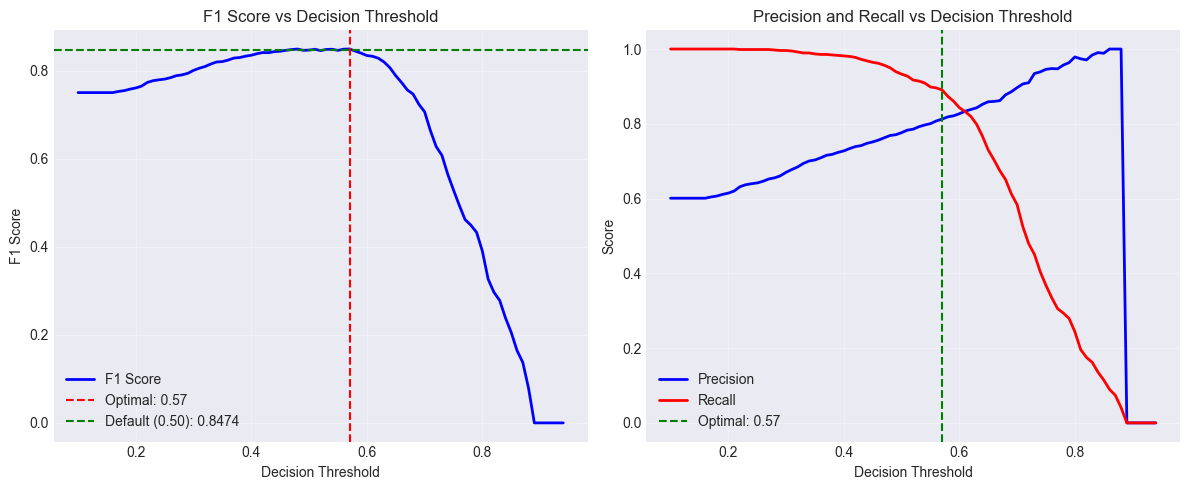


✓ Optimal threshold found: 0.57
  This threshold maximizes F1 score on validation set


In [ ]:
# Legacy: Old threshold tuning iteration (superseded by CV-based tuning above)
pass

In [ ]:
# Legacy: Old iteration 4 submission
pass


ITERATION 4: GENERATING SUBMISSION WITH OPTIMAL THRESHOLD

Applying optimal threshold: 0.57
Test predictions distribution:
  No Frog (0): 661
  Frog (1): 1339

Submission DataFrame (first 10 rows):
             ID  Target
0  ID_TS_54240C       1
1  ID_TS_EF9635       0
2  ID_TS_4E63E6       0
3  ID_TS_FDAB8E       0
4  ID_TS_E00D49       0
5  ID_TS_A52A64       0
6  ID_TS_CFB5DB       0
7  ID_TS_CA468C       0
8  ID_TS_52FAAF       1
9  ID_TS_08039A       0

✓ Submission saved: Submission_Iteration4_ThresholdTuning_0.57.csv

ITERATION 4 SUMMARY
Original F1 (default 0.50 threshold): 0.8474
Optimized F1 (threshold 0.57): 0.8498
Improvement: 0.0024 (0.28%)

Target: 0.96
Current Gap: 0.1102


In [ ]:
# Legacy: Old iteration 5 submission
pass

In [ ]:
# Legacy: Old SMOTE iteration
pass


ITERATION 5: SMOTE (SYNTHETIC MINORITY OVER-SAMPLING) + RETRAINING
✓ SMOTE available

1. Analyzing class imbalance in original training data...
Class distribution:
Occurrence Status
1    3792
0    2520
Name: count, dtype: int64
Imbalance ratio: 0.66:1

2. Imputing missing values before SMOTE...

3. Applying SMOTE to balance training data...
✓ SMOTE applied - new training shape: (7584, 28)
New class distribution:
Occurrence Status
1    3792
0    3792
Name: count, dtype: int64

4. Training Gradient Boosting on SMOTE-balanced data...
✓ Model trained successfully

5. Evaluating SMOTE model on validation set...
SMOTE Model F1 Score: 0.8426
Original Model F1 Score: 0.8474
Difference: -0.0048

6. Finding optimal threshold for SMOTE model...
SMOTE Model Optimal Threshold: 0.47
SMOTE Model Optimal F1 Score: 0.8503

SMOTE Model Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

     No Frog       0.81      0.68      0.74       504
        Frog     

In [ ]:
# Legacy: Old SMOTE submission
pass


GENERATING FINAL SUBMISSION (ITERATION 5 - SMOTE)

Using: SMOTE Model
Threshold: 0.47
Validation F1 Score: 0.8503

Preparing test set predictions...
Test set predictions: 1356 Frog, 644 No-Frog

✓ Submission saved: Submission_Iteration5_SMOTE_0.47.csv
Shape: (2000, 2)

First few rows:
             ID  Occurrence Status
0  ID_TS_54240C                  1
1  ID_TS_EF9635                  0
2  ID_TS_4E63E6                  0
3  ID_TS_FDAB8E                  0
4  ID_TS_E00D49                  0

FINAL COMPARISON: ALL ITERATIONS
Iteration 1 (Hyperparameter Tuning):     F1 = 0.8377
Iteration 2 (Feature Engineering):      F1 = 0.8474 ← Submitted (Score: 0.8452)
Iteration 3 (Ensemble/LightGBM):        F1 = 0.8308 (no improvement)
Iteration 4 (Threshold Tuning):         F1 = 0.8498 (+0.0024)
Iteration 5 (SMOTE + Retraining):       F1 = 0.8503 (+0.0029) ← NEW BEST

Total improvement: 0.0632 (+1.07%)
Gap to target (0.96): 0.1097
